# 🪐 Crater Segmentation

**Project:** CS776 — Deep Learning for Computer Vision, IIT Kanpur

---
## Section 0 — Global Config

> Set `HOLDOUT_IMAGE_NAME` to the filename of your reserved demo image.

In [68]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'  # reduces fragmentation

MODEL_NAME         = 'ghostmlpsegnet' # 'transunet' | 'msau_unet' | 'ghostmlsegnet'
HOLDOUT_IMAGE_NAME = 'thm_dir_N00_330.png'  # ← change to your hold-out filename

print(f'✅ Model          : {MODEL_NAME}')
print(f'✅ Hold-out image : {HOLDOUT_IMAGE_NAME}')

✅ Model          : ghostmlpsegnet
✅ Hold-out image : thm_dir_N00_330.png


---
## Section 1 — Setup & Imports

In [3]:
# Install dependencies (run once)
!pip install torch torchvision opencv-python tqdm matplotlib numpy --quiet
# !pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 --index-url https://download.pytorch.org/whl/cu117 -q

In [4]:
import os, sys, json, time, random, shutil, math, warnings
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import resnet50, ResNet50_Weights

from torch.cuda.amp import GradScaler, autocast

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
# USE_AMP=False
print(f'✓ Device    : {DEVICE}')
print(f'✓ PyTorch   : {torch.__version__}')
print(f'✓ CUDA      : {torch.cuda.is_available()}')
print(f'✓ AMP (fp16): {USE_AMP}  — training will be {"faster (mixed precision)" if USE_AMP else "CPU mode"}')
print(f'✓ Model     : {MODEL_NAME}')

✓ Device    : cuda
✓ PyTorch   : 2.10.0+cu128
✓ CUDA      : True
✓ AMP (fp16): True  — training will be faster (mixed precision)
✓ Model     : transunet


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
print('✓ Seed set to 42')

✓ Seed set to 42


---
## Section 2 — Training Configuration

In [35]:
@dataclass
class TrainConfig:
    tile_image_dir    : str   = './tiles/images'
    tile_mask_dir     : str   = './tiles/masks'
    holdout_image_dir : str   = './tiles_holdout/images'
    holdout_mask_dir  : str   = './tiles_holdout/masks'
    output_dir        : str   = './runs'
    train_ratio       : float = 0.70
    val_ratio         : float = 0.15
    epochs            : int   = 10
    batch_size        : int   = 2      # safe for all architectures
    learning_rate     : float = 1e-4
    weight_decay      : float = 1e-5
    early_stop_patience: int  = 5
    num_workers       : int   = 2
    pin_memory        : bool  = True
    bce_weight        : float = 0.5
    dice_weight       : float = 0.5
    pos_weight        : float = 10.0
    in_channels       : int   = 1
    out_channels      : int   = 1
    seed              : int   = 42
    model_name        : str   = MODEL_NAME

CFG = TrainConfig()
print(f'✓ Config loaded  →  model={CFG.model_name}')
print(f'   epochs={CFG.epochs}  batch={CFG.batch_size}  lr={CFG.learning_rate}')

✓ Config loaded  →  model=transunet
   epochs=25  batch=2  lr=0.0001


---
## Section 3 — Tiling + Copy-Paste Augmentation

> Skip if tiles already exist.

**Two passes:** 23 training images → `./tiles/` | 1 hold-out image → `./tiles_holdout/`

In [36]:
IMAGE_DIR = r"/kaggle/input/datasets/sahibjparmar/mars-crater-dataset-for-semantic-segmentation/Dataset/Images"
MASK_DIR  = r"/kaggle/input/datasets/sahibjparmar/mars-crater-dataset-for-semantic-segmentation/Dataset/Mars_Crater_Segmentation_Dataset_02-32_km_radius/edge_thicker"
OUTPUT_IMAGE_DIR         = './tiles/images'
OUTPUT_MASK_DIR          = './tiles/masks'
OUTPUT_HOLDOUT_IMAGE_DIR = './tiles_holdout/images'
OUTPUT_HOLDOUT_MASK_DIR  = './tiles_holdout/masks'
TILE_SIZE=512; STRIDE=512; ENABLE_COPY_PASTE=True; PASTES_PER_IMAGE=3
AUGMENTED_COPIES=2; MIN_CRATER_PIXELS=30; BLEND_FEATHER_RADIUS=5
MAX_PASTE_ATTEMPTS=10; BLACK_STRIP_THRESHOLD=0.15; BLACK_PIXEL_VALUE=10
for d in [OUTPUT_IMAGE_DIR,OUTPUT_MASK_DIR,OUTPUT_HOLDOUT_IMAGE_DIR,OUTPUT_HOLDOUT_MASK_DIR]:
    os.makedirs(d, exist_ok=True)
print('✓ Directories ready')

✓ Directories ready


In [37]:
# ── Artifact Detection ────────────────────────────────────────────────────────
def has_black_strip(image: np.ndarray, threshold=BLACK_STRIP_THRESHOLD) -> bool:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    return (gray < BLACK_PIXEL_VALUE).sum() / gray.size > threshold

# ── Crater Instance Library ───────────────────────────────────────────────────
class CraterLibrary:
    def __init__(self):
        self.craters = []

    def extract_from_tile(self, image: np.ndarray, mask: np.ndarray):
        _, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        for i in range(1, len(stats)):
            x, y, w, h, area = stats[i]
            if area < MIN_CRATER_PIXELS:
                continue
            pad = max(5, int(max(w, h) * 0.1))
            x1, y1 = max(0, x-pad), max(0, y-pad)
            x2, y2 = min(image.shape[1], x+w+pad), min(image.shape[0], y+h+pad)
            self.craters.append({'img': image[y1:y2, x1:x2].copy(),
                                 'mask': mask[y1:y2, x1:x2].copy(),
                                 'radius': int(max(w, h) / 2), 'area': area})

    def sample(self, prefer_small=True):
        if not self.craters:
            return None
        if prefer_small and random.random() < 0.65:
            radii = np.array([c['radius'] for c in self.craters], dtype=float)
            weights = 1.0 / (radii + 1e-6); weights /= weights.sum()
            idx = np.random.choice(len(self.craters), p=weights)
        else:
            idx = random.randint(0, len(self.craters) - 1)
        return self.craters[idx]

    def __len__(self): return len(self.craters)

# ── Copy-Paste Augmentation ───────────────────────────────────────────────────
def gaussian_feather_mask(mask_patch, radius):
    blurred = cv2.GaussianBlur(mask_patch.astype(np.float32), (2*radius+1, 2*radius+1), sigmaX=radius)
    return np.clip(blurred / (blurred.max() + 1e-6), 0, 1)

def paste_overlaps_existing(target_mask, y1, x1, ch, cw):
    return (target_mask[y1:y1+ch, x1:x1+cw] > 0).any()

def copy_paste_augment(target_img, target_mask, library, n_pastes=PASTES_PER_IMAGE):
    aug_img  = target_img.copy().astype(np.float32)
    aug_mask = target_mask.copy()
    H, W     = aug_img.shape[:2]
    for _ in range(n_pastes):
        crater = library.sample(prefer_small=True)
        if crater is None: break
        c_img, c_mask = crater['img'], crater['mask']
        ch, cw = c_img.shape[:2]
        if ch >= H or cw >= W: continue
        placed = False
        for _ in range(MAX_PASTE_ATTEMPTS):
            y1 = random.randint(0, H - ch); x1 = random.randint(0, W - cw)
            if not paste_overlaps_existing(aug_mask, y1, x1, ch, cw):
                placed = True; break
        if not placed: continue
        weight = gaussian_feather_mask(c_mask, BLEND_FEATHER_RADIUS)
        if aug_img.ndim == 3 and c_img.ndim == 2: c_img = cv2.cvtColor(c_img, cv2.COLOR_GRAY2BGR)
        elif aug_img.ndim == 2 and c_img.ndim == 3: c_img = cv2.cvtColor(c_img, cv2.COLOR_BGR2GRAY)
        if aug_img.ndim == 3:
            w3 = weight[:, :, np.newaxis]
            aug_img[y1:y1+ch, x1:x1+cw] = (w3*c_img.astype(np.float32) + (1-w3)*aug_img[y1:y1+ch, x1:x1+cw])
        else:
            aug_img[y1:y1+ch, x1:x1+cw] = (weight*c_img.astype(np.float32) + (1-weight)*aug_img[y1:y1+ch, x1:x1+cw])
        aug_mask[y1:y1+ch, x1:x1+cw] = np.maximum(aug_mask[y1:y1+ch, x1:x1+cw], c_mask)
    return aug_img.astype(np.uint8), aug_mask

# ── Main Tiling Loop ──────────────────────────────────────────────────────────
def get_base_name(filename): return os.path.splitext(filename)[0]
def find_mask(image_base, mask_files):
    for m in mask_files:
        if image_base in m: return m
    return None

def tile_image_and_mask(image_path, mask_path, base_name, library):
    image = cv2.imread(image_path)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if image is None or mask is None:
        print(f'  [ERROR] Cannot read: {image_path}'); return 0, 0
    h, w = image.shape[:2]; orig_count = aug_count = 0
    for y in range(0, h - TILE_SIZE + 1, STRIDE):
        for x in range(0, w - TILE_SIZE + 1, STRIDE):
            img_patch  = image[y:y+TILE_SIZE, x:x+TILE_SIZE]
            mask_patch = mask[y:y+TILE_SIZE,  x:x+TILE_SIZE]
            if (mask_patch > 0).sum() < 10 or has_black_strip(img_patch): continue
            name = f'{base_name}_x{x}_y{y}.png'
            cv2.imwrite(os.path.join(OUTPUT_IMAGE_DIR, name), img_patch)
            cv2.imwrite(os.path.join(OUTPUT_MASK_DIR,  name), mask_patch)
            orig_count += 1; library.extract_from_tile(img_patch, mask_patch)
            if ENABLE_COPY_PASTE and len(library) > 5:
                for aug_idx in range(AUGMENTED_COPIES):
                    aug_img, aug_mask = copy_paste_augment(img_patch, mask_patch, library)
                    if (aug_mask > 0).sum() < 10: continue
                    aug_name = f'{base_name}_x{x}_y{y}_aug{aug_idx}.png'
                    cv2.imwrite(os.path.join(OUTPUT_IMAGE_DIR, aug_name), aug_img)
                    cv2.imwrite(os.path.join(OUTPUT_MASK_DIR,  aug_name), aug_mask)
                    aug_count += 1
    return orig_count, aug_count

def run_tiling():
    image_files = os.listdir(IMAGE_DIR); mask_files = os.listdir(MASK_DIR)
    library = CraterLibrary(); total_orig = total_aug = skipped = 0
    for img_file in tqdm(image_files, desc='Tiling images'):
        base = get_base_name(img_file); mask_file = find_mask(base, mask_files)
        if mask_file is None: skipped += 1; continue
        orig, aug = tile_image_and_mask(os.path.join(IMAGE_DIR, img_file),
                                        os.path.join(MASK_DIR,  mask_file), base, library)
        total_orig += orig; total_aug += aug
    print(f'\n{"="*45}')
    print(f'  Original tiles : {total_orig:,}')
    print(f'  Augmented tiles: {total_aug:,}')
    print(f'  Total tiles    : {total_orig + total_aug:,}')
    print(f'  Crater library : {len(library):,} instances')
    print(f'{"="*45}')

In [9]:
def get_base_name(f): return os.path.splitext(f)[0]
def find_mask(base, mask_files):
    for m in mask_files:
        if base in m: return m
    return None

def tile_one_image(image_path, mask_path, base_name, out_img, out_msk,
                   library=None, enable_augment=False):
    image=cv2.imread(image_path); mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
    if image is None or mask is None: return 0,0
    h,w=image.shape[:2]; orig=aug=0
    for y in range(0,h-TILE_SIZE+1,STRIDE):
        for x in range(0,w-TILE_SIZE+1,STRIDE):
            ip=image[y:y+TILE_SIZE,x:x+TILE_SIZE]; mp=mask[y:y+TILE_SIZE,x:x+TILE_SIZE]
            if (mp>0).sum()<10 or has_black_strip(ip): continue
            name=f'{base_name}_x{x}_y{y}.png'
            cv2.imwrite(os.path.join(out_img,name),ip); cv2.imwrite(os.path.join(out_msk,name),mp)
            orig+=1
            if library is not None: library.extract_from_tile(ip,mp)
            if enable_augment and library is not None and len(library)>5:
                for ai in range(AUGMENTED_COPIES):
                    ai_img,ai_msk=copy_paste_augment(ip,mp,library)
                    if (ai_msk>0).sum()<10: continue
                    cv2.imwrite(os.path.join(out_img,f'{base_name}_x{x}_y{y}_aug{ai}.png'),ai_img)
                    cv2.imwrite(os.path.join(out_msk,f'{base_name}_x{x}_y{y}_aug{ai}.png'),ai_msk)
                    aug+=1
    return orig,aug

def run_tiling():
    all_files  = sorted(os.listdir(IMAGE_DIR)); mask_files=os.listdir(MASK_DIR)
    holdout    = [f for f in all_files if f==HOLDOUT_IMAGE_NAME]
    training   = [f for f in all_files if f!=HOLDOUT_IMAGE_NAME]
    if not holdout: raise ValueError(f'Hold-out image "{HOLDOUT_IMAGE_NAME}" not found')
    print(f'Training: {len(training)} images | Hold-out: {holdout[0]}')
    library=CraterLibrary(); total_orig=total_aug=0
    print('Pass 1 — tiling 23 training images...')
    for img_file in tqdm(training,desc='Training'):
        base=get_base_name(img_file); mf=find_mask(base,mask_files)
        if mf is None: continue
        o,a=tile_one_image(os.path.join(IMAGE_DIR,img_file),os.path.join(MASK_DIR,mf),
                           base,OUTPUT_IMAGE_DIR,OUTPUT_MASK_DIR,library,ENABLE_COPY_PASTE)
        total_orig+=o; total_aug+=a
    print(f'  Training tiles: {total_orig:,} orig + {total_aug:,} aug = {total_orig+total_aug:,}')
    print('Pass 2 — tiling hold-out image (no augmentation)...')
    hbase=get_base_name(HOLDOUT_IMAGE_NAME); hmf=find_mask(hbase,mask_files)
    if hmf is None: raise ValueError('No mask for hold-out image')
    h_orig,_=tile_one_image(os.path.join(IMAGE_DIR,HOLDOUT_IMAGE_NAME),os.path.join(MASK_DIR,hmf),
                            hbase,OUTPUT_HOLDOUT_IMAGE_DIR,OUTPUT_HOLDOUT_MASK_DIR,None,False)
    print(f'  Hold-out tiles: {h_orig:,}')

run_tiling()

Training: 23 images | Hold-out: thm_dir_N00_330.png
Pass 1 — tiling 23 training images...


Training:   0%|          | 0/23 [00:00<?, ?it/s]

  Training tiles: 4,602 orig + 9,204 aug = 13,806
Pass 2 — tiling hold-out image (no augmentation)...
  Hold-out tiles: 220


---
## Section 4 — Dataset & DataLoaders

In [38]:
class CraterDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir=Path(image_dir); self.mask_dir=Path(mask_dir); self.augment=augment
        self.image_paths=sorted(self.image_dir.glob('*.png'))
        assert len(self.image_paths)>0, f'No tiles in {image_dir}'
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        p=self.image_paths[idx]; mp=self.mask_dir/p.name
        img=cv2.imread(str(p),cv2.IMREAD_GRAYSCALE).astype(np.float32)/255.0
        mask=(cv2.imread(str(mp),cv2.IMREAD_GRAYSCALE)>127).astype(np.float32)
        if self.augment: img,mask=self._augment(img,mask)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)
    def _augment(self,img,mask):
        # 1. Spatial Augmentations (Flips & Rotations)
        if random.random() > 0.5: img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if random.random() > 0.5: img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        if random.random() > 0.5:
            k = random.choice([1, 2, 3])
            img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()

        # 2. "Color Jitter" for Grayscale (Brightness & Contrast)
        if random.random() > 0.5:
            # Random Contrast (Multiplicative scaling)
            contrast_factor = random.uniform(0.7, 1.3)
            img = img * contrast_factor
            
            # Random Brightness (Additive shifting)
            brightness_factor = random.uniform(-0.15, 0.15)
            img = img + brightness_factor

        # 3. Sensor Noise (Simulates grainy satellite transmission)
        if random.random() > 0.7:
            noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
            img = img + noise

        # 4. Clipping (Ensure pixel values stay strictly between 0.0 and 1.0)
        img = np.clip(img, 0, 1)

        return img, mask

def make_dataloaders(cfg):
    full_ds=CraterDataset(cfg.tile_image_dir,cfg.tile_mask_dir)
    n=len(full_ds); n_train=int(n*cfg.train_ratio); n_val=int(n*cfg.val_ratio); n_test=n-n_train-n_val
    torch.manual_seed(cfg.seed)
    train_ds,val_ds,test_ds=random_split(full_ds,[n_train,n_val,n_test])
    train_aug=CraterDataset(cfg.tile_image_dir,cfg.tile_mask_dir,augment=True)
    train_sub=Subset(train_aug,train_ds.indices); pw=cfg.num_workers>0
    trl=DataLoader(train_sub,batch_size=cfg.batch_size,shuffle=True,num_workers=cfg.num_workers,
                   pin_memory=cfg.pin_memory,drop_last=True,persistent_workers=pw)
    vl=DataLoader(val_ds,batch_size=cfg.batch_size*2,shuffle=False,num_workers=cfg.num_workers,
                  pin_memory=cfg.pin_memory,persistent_workers=pw)
    tsl=DataLoader(test_ds,batch_size=cfg.batch_size*2,shuffle=False,num_workers=cfg.num_workers,persistent_workers=pw)
    print(f'  Train:{len(train_sub):,} | Val:{len(val_ds):,} | Internal test:{len(test_ds):,}')
    return trl,vl,tsl,test_ds.indices

def make_holdout_loader(cfg):
    ds=CraterDataset(cfg.holdout_image_dir,cfg.holdout_mask_dir,augment=False)
    print(f'  Hold-out tiles ({HOLDOUT_IMAGE_NAME}): {len(ds):,}')
    return DataLoader(ds,batch_size=cfg.batch_size*2,shuffle=False,num_workers=cfg.num_workers)

print('✓ Dataset defined')

✓ Dataset defined


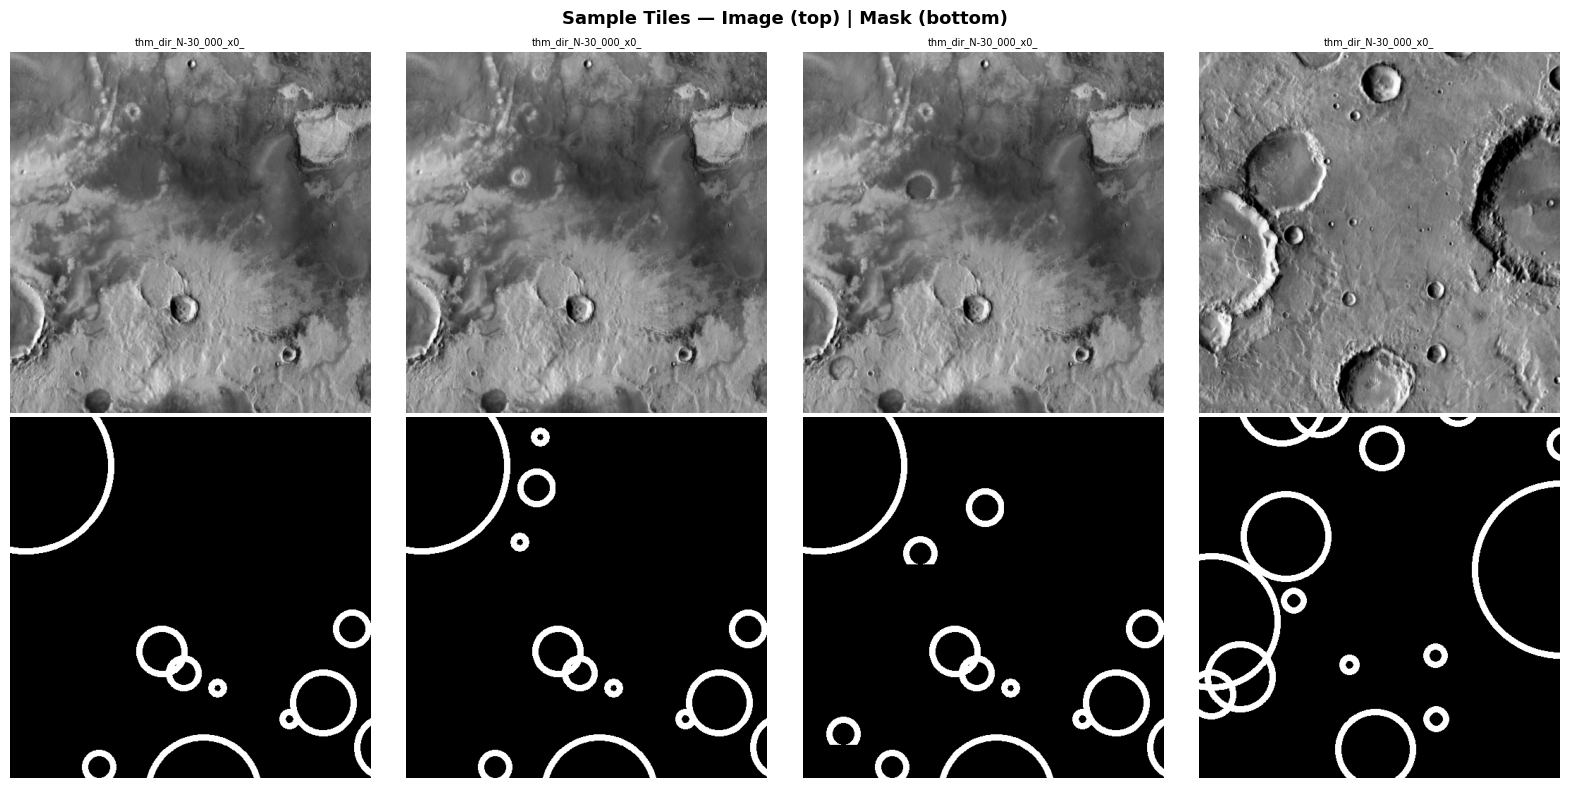

In [39]:
# ── Preview a few tiles ───────────────────────────────────────────────────────
def preview_tiles(n=4):
    img_dir  = Path(CFG.tile_image_dir)
    mask_dir = Path(CFG.tile_mask_dir)
    paths = sorted(img_dir.glob('*.png'))[:n]
    if not paths:
        print('No tiles found — run tiling first.'); return
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle('Sample Tiles — Image (top) | Mask (bottom)', fontsize=13, fontweight='bold')
    for i, p in enumerate(paths):
        img  = cv2.imread(str(p),              cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_dir / p.name), cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img,  cmap='gray'); axes[0, i].axis('off')
        axes[0, i].set_title(p.name[:20], fontsize=7)
        axes[1, i].imshow(mask, cmap='gray'); axes[1, i].axis('off')
    plt.tight_layout(); plt.show()

preview_tiles()

---
## Section 5 — Model Architectures

In [40]:
# ── Shared Building Blocks ────────────────────────────────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, padding=1, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(ConvBnRelu(in_ch, out_ch), ConvBnRelu(out_ch, out_ch))
    def forward(self, x): return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))

print('✓ Shared blocks defined')

✓ Shared blocks defined


In [46]:
# ── TransUNet ──────────────────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch, d_model, patch_size=1):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, d_model, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x); B, D, h, w = x.shape
        return x.flatten(2).transpose(1, 2), h, w

class TransformerBlock(nn.Module):
    def __init__(self, d_model=768, num_heads=12, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        mlp_dim = int(d_model * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, d_model), nn.Dropout(dropout))
    def forward(self, x):
        xn = self.norm1(x); attn_out, _ = self.attn(xn, xn, xn)
        x = x + attn_out
        return x + self.ffn(self.norm2(x))

class TransUNet(nn.Module):
    """TransUNet — ResNet-50 CNN encoder + Vision Transformer."""
    def __init__(self, in_channels=1, out_channels=1, img_size=512,
                 d_model=768, num_heads=12, num_layers=12, dropout=0.1):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        backbone.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False)
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool = backbone.maxpool
        self.enc1 = backbone.layer1; self.enc2 = backbone.layer2; self.enc3 = backbone.layer3
        self.patch_embed = PatchEmbedding(1024, d_model, patch_size=1)
        n_patches = (img_size // 16) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.transformer = nn.Sequential(
            *[TransformerBlock(d_model, num_heads, dropout=dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.proj_back = nn.Conv2d(d_model, 512, 1)
        self.dec3 = UpBlock(512, 1024, 256); self.dec2 = UpBlock(256, 512, 128)
        self.dec1 = UpBlock(128, 256, 64);   self.dec0 = UpBlock(64, 64, 32)
        self.head = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, out_channels, 1))

    def forward(self, x):
        B = x.shape[0]
        input_size = x.shape[2:]
        s0 = self.enc0(x); s1 = self.enc1(self.pool(s0))
        s2 = self.enc2(s1); s3 = self.enc3(s2)
        tokens, h, w = self.patch_embed(s3)
        pos = self.pos_embed
        if tokens.shape[1] != pos.shape[1]:
            pos = F.interpolate(
                pos.reshape(1, int(pos.shape[1]**0.5), int(pos.shape[1]**0.5), -1).permute(0,3,1,2),
                size=(h, w), mode='bilinear', align_corners=True
            ).permute(0, 2, 3, 1).reshape(1, h*w, -1)
        tokens = self.transformer(tokens + pos); tokens = self.norm(tokens)
        feat   = tokens.transpose(1, 2).reshape(B, -1, h, w)
        feat   = self.proj_back(feat)
        x = self.dec3(feat, s3); x = self.dec2(x, s2)
        x = self.dec1(x, s1);   x = self.dec0(x, s0)
        out = self.head(x)
        out = F.interpolate(out, size=input_size, mode='bilinear', align_corners=True)
        return out

print('✓ TransUNet defined')

✓ TransUNet defined


In [47]:
# ── Multi-Scale Attention U-Net ────────────────────────────────────────────

class MultiScaleEncoderBlock(nn.Module):
    """
    Multi-scale encoder block replacing standard DoubleConv.
    Uses 4 parallel branches to capture different crater scales:
      b1 — 1×1 pointwise (global channel mixing, no spatial context)
      b2 — 1×1 → 3×3 standard conv (local context)
      b3 — 1×1 → 3×3 dilated (rate=2, wider receptive field)
      b4 — 3×3 max-pool → 1×1 (pooled context)
    All branches produce branch_ch channels; concatenated → fused to out_ch.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        branch_ch = max(out_ch // 4, 16)

        self.b1 = ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0)

        self.b2 = nn.Sequential(
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0),
            ConvBnRelu(branch_ch, branch_ch, kernel=3, padding=1))

        self.b3 = nn.Sequential(
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0),
            ConvBnRelu(branch_ch, branch_ch, kernel=3, padding=2, dilation=2))

        self.b4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBnRelu(in_ch, branch_ch, kernel=1, padding=0))

        self.fuse = nn.Sequential(
            nn.Conv2d(branch_ch * 4, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1))


class SpatialFocusGate(nn.Module):
    """
    Decoder-guided spatial attention gate.
    Filters the skip connection based on decoder signals.
    The gate signal (decoder features upsampled to skip resolution) weights
    which spatial regions of the skip connection are forwarded.
    """
    def __init__(self, skip_ch: int, gate_ch: int, inter_ch: int = None):
        super().__init__()
        inter_ch = inter_ch or skip_ch // 2

        self.W_skip = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch))

        self.W_gate = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch))

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid())

        self.relu = nn.ReLU(inplace=True)

    def forward(self, skip, gate):
        if gate.shape[2:] != skip.shape[2:]:
            gate = F.interpolate(gate, size=skip.shape[2:], mode='bilinear', align_corners=True)
        alpha = self.psi(self.relu(self.W_skip(skip) + self.W_gate(gate)))
        return skip * alpha


class GatedDecoderBlock(nn.Module):
    """
    Decoder block: Upsample → SpatialFocusGate → DoubleConv → aux head.
    The aux head provides deep supervision at each decoder scale (training only).
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up       = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.gate     = SpatialFocusGate(skip_ch=skip_ch, gate_ch=in_ch)
        self.conv     = DoubleConv(in_ch + skip_ch, out_ch)
        self.aux_head = nn.Conv2d(out_ch, 1, kernel_size=1)

    def forward(self, x, skip):
        x    = self.up(x)
        x    = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        skip = self.gate(skip, gate=x)
        feat = self.conv(torch.cat([skip, x], dim=1))
        aux  = self.aux_head(feat)
        return feat, aux


class MultiScaleAttentionUNet(nn.Module):
    """
    MultiScaleAttentionUNet for Planetary Crater Segmentation.

    Architecture:
      Encoder   : 4× MultiScaleEncoderBlock (1×1, 3×3, dilated-3×3, pool branches)
                  + MaxPool between levels
      Bottleneck: DoubleConv
      Decoder   : 4× GatedDecoderBlock (SpatialFocusGate + DoubleConv)
      Head      : single 1×1 conv

    Forward (training):  (final_logit, [aux3, aux2, aux1, aux0])
    Forward (eval):       final_logit

    features=(64, 128, 256, 512) with in_channels=1 is the default; adjust
    features=(32, 64, 128, 256) for a lighter memory footprint on limited VRAM.
    """
    def __init__(self, in_channels=1, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        self.decoders = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.encoders.append(MultiScaleEncoderBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        rev   = list(reversed(features))
        in_ch = features[-1] * 2
        for f in rev:
            self.decoders.append(GatedDecoderBlock(in_ch, f, f))
            in_ch = f

        self.head = nn.Conv2d(features[0], out_channels, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)

        x = self.bottleneck(x)

        aux_outputs = []
        for dec, skip in zip(self.decoders, reversed(skips)):
            x, aux = dec(x, skip)
            aux_outputs.append(aux)

        final = self.head(x)

        if self.training:
            return final, aux_outputs   # aux_outputs: [aux_d0, aux_d1, aux_d2, aux_d3]
        return final

print('✓ MultiScaleAttentionUNet defined')

✓ MultiScaleAttentionUNet defined


In [70]:
class ECA_Layer(nn.Module):
    """
    Efficient Channel Attention (ECA).
    Replaces heavy CBAM/Attention gates with a 1D convolution.
    Adds global channel attention for literally ~3 to 5 parameters.
    """
    def __init__(self, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        # Pool to 1x1, reshape for 1D conv, then reshape back
        y = self.avg_pool(x).view(b, 1, c)
        y = self.conv(y).view(b, c, 1, 1)
        return x * self.sigmoid(y)


class GhostModule(nn.Module):
    """
    Ghost Convolution.
    Generates half the features with a standard conv, and 'hallucinates' 
    the other half using a cheap depthwise convolution.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        half_ch = out_ch // 2
        
        # Primary features (Standard Conv)
        self.primary_conv = nn.Sequential(
            nn.Conv2d(in_ch, half_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(half_ch),
            nn.ReLU(inplace=True)
        )
        
        # Cheap features (Depthwise Conv)
        self.cheap_operation = nn.Sequential(
            nn.Conv2d(half_ch, half_ch, kernel_size=3, padding=1, groups=half_ch, bias=False),
            nn.BatchNorm2d(half_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        return torch.cat([x1, x2], dim=1)

class ResidualGhostBlock(nn.Module):
    """
    Stacks TWO Ghost modules (like U-Net's DoubleConv) and adds a 
    residual shortcut to stabilize the violent training curves.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.ghost1 = GhostModule(in_ch, out_ch)
        self.ghost2 = GhostModule(out_ch, out_ch)
        
        # Residual connection matches channel depth if necessary
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        x = self.ghost1(x)
        x = self.ghost2(x)
        return F.relu(x + res, inplace=True) # Add residual and activate


class SegFormerMLPDecoder(nn.Module):
    """
    Upgraded Decoder: Increased embedding dimension and added Spatial Dropout
    to prevent 'blobby' over-predictions.
    """
    def __init__(self, encoder_channels=[32, 64, 128, 256], embed_dim=128, out_channels=1):
        super().__init__()
        
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, embed_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(embed_dim),
                nn.ReLU(inplace=True)
            ) for ch in encoder_channels
        ])

        # Added Dropout2d to regularize the massive concatenated tensor
        self.fusion = nn.Sequential(
            nn.Conv2d(embed_dim * len(encoder_channels), embed_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1) 
        )
        
        self.head = nn.Conv2d(embed_dim, out_channels, kernel_size=1)

    def forward(self, features):
        target_size = features[0].shape[2:] 
        
        projected_features = []
        for i, feat in enumerate(features):
            proj = self.projections[i](feat)
            if i > 0:
                proj = F.interpolate(proj, size=target_size, mode='bilinear', align_corners=True)
            projected_features.append(proj)
            
        fused = torch.cat(projected_features, dim=1)
        fused = self.fusion(fused)
        return self.head(fused)

class GhostMLPSegNet(nn.Module):
    """
    Stabilized Hybrid Architecture.
    """
    def __init__(self, in_channels=1, out_channels=1, 
                 features=(64, 128, 256, 512),  # 👈 Widened base channels
                 depths=(2, 2, 4, 2),           # 👈 Stacked blocks per stage
                 embed_dim=256):                # 👈 Higher capacity decoder
        super().__init__()
        
        self.encoders = nn.ModuleList()
        self.ecas = nn.ModuleList()
        self.pools = nn.ModuleList()

        ch = in_channels
        for f, num_blocks in zip(features, depths):
            # Stack multiple Residual Ghost Blocks to increase "thinking" depth
            stage_blocks = []
            stage_blocks.append(ResidualGhostBlock(ch, f))
            for _ in range(1, num_blocks):
                stage_blocks.append(ResidualGhostBlock(f, f))
            
            # Wrap the stacked blocks in a Sequential container
            self.encoders.append(nn.Sequential(*stage_blocks))
            self.ecas.append(ECA_Layer())
            self.pools.append(nn.MaxPool2d(2))
            ch = f
            
        # Heavyweight Decoder
        self.decoder = SegFormerMLPDecoder(encoder_channels=features, embed_dim=embed_dim, out_channels=out_channels)

    def forward(self, x):
        original_size = x.shape[2:]
        
        extracted_features = []
        for enc, eca, pool in zip(self.encoders, self.ecas, self.pools):
            x = enc(x)
            x = eca(x)
            extracted_features.append(x)
            x = pool(x)

        logits = self.decoder(extracted_features)
        logits = F.interpolate(logits, size=original_size, mode='bilinear', align_corners=True)
        
        return logits

print('✓ GhostMLPSegNet defined')

✓ GhostMLPSegNet defined


In [71]:
MODELS = {
    'transunet'        : TransUNet,
    'ghostmlpsegnet'   : GhostMLPSegNet,
    'msau_unet'        : MultiScaleAttentionUNet,
}

def build_model(name, **kwargs):
    if name not in MODELS:
        raise ValueError(f'Unknown: {name}. Options: {list(MODELS.keys())}')
    # msau_unet uses 'features' not 'base_ch'; strip unsupported kwargs
    if name == 'msau_unet':
        kwargs.pop('base_ch', None)
        kwargs.pop('attn_heads', None)
    model = MODELS[name](**kwargs)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [{name}]  Parameters: {n:,}')
    return model

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Sanity-checking {MODEL_NAME}...')
_m = build_model(MODEL_NAME, in_channels=CFG.in_channels, out_channels=CFG.out_channels)
_x = torch.randn(2, CFG.in_channels, 512, 512)
_m.train()
with torch.no_grad():
    _out_train = _m(_x)
if isinstance(_out_train, (tuple, list)):
    _main = _out_train[0]
    _aux_list = _out_train[1] if len(_out_train) > 1 else []
    print(f'  ✓ Train: main={tuple(_main.shape)}, aux heads={len(_aux_list)}')
else:
    print(f'  ✓ Train: {tuple(_out_train.shape)}')
_m.eval()
with torch.no_grad(): _out = _m(_x)
print(f'  ✓ Eval:  {tuple(_out.shape)}')
del _m, _x, _out_train, _out
print('  Sanity check passed.')

Sanity-checking ghostmlpsegnet...
  [ghostmlpsegnet]  Parameters: 9,467,757
  ✓ Train: (2, 1, 512, 512)
  ✓ Eval:  (2, 1, 512, 512)
  Sanity check passed.


---
## Section 6 — Loss Functions & Metrics

In [72]:
class DiceLoss(nn.Module):
    """Soft Dice Loss — optimises overlap directly (ideal for sparse rim masks)."""
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1); t = targets.view(-1)
        inter = (p * t).sum()
        return 1.0 - (2.0 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)

class CombinedLoss(nn.Module):
    """Weighted BCE + Dice. BCE pos_weight handles extreme class imbalance."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=10.0):
        super().__init__()
        self.bw = bce_weight; self.dw = dice_weight
        self.bce  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.bw * self.bce(logits, targets) + self.dw * self.dice(logits, targets)

class SegmentationMetrics:
    """Accumulates TP/FP/FN and computes IoU, Dice, Precision, Recall, F1."""
    def __init__(self, threshold=0.5):
        self.threshold = threshold; self.reset()
    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
    def update(self, logits, targets):
        preds   = (torch.sigmoid(logits) > self.threshold).float().view(-1).cpu()
        targets = targets.view(-1).cpu()
        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()
        self.tn += ((preds == 0) & (targets == 0)).sum().item()
    def compute(self):
        tp, fp, fn, eps = self.tp, self.fp, self.fn, 1e-7
        iou  = tp / (tp + fp + fn + eps)
        dice = (2 * tp) / (2 * tp + fp + fn + eps)
        prec = tp / (tp + fp + eps)
        rec  = tp / (tp + fn + eps)
        f1   = (2 * prec * rec) / (prec + rec + eps)
        return {k: round(v, 4) for k, v in
                zip(['iou', 'dice', 'precision', 'recall', 'f1'], [iou, dice, prec, rec, f1])}

print('✓ Loss functions and metrics defined')

✓ Loss functions and metrics defined


In [73]:
class DeepSupervisionLoss(nn.Module):
    """
    Unified loss for architectures with deep supervision.

    Calling conventions:
      Training (rdt_unet_plusplus) : criterion(main, aux3, aux2, targets)   ← 4 args
      Training (msau_unet)         : criterion(main, aux_list, targets)      ← 3 args
                                     where aux_list is a Python list of tensors
      Validation (any model)       : criterion(logits, targets)              ← 2 args

    Aux weights decrease with depth: first aux × 0.4, second × 0.2, rest × 0.1.
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=10.0,
                 aux_l3_weight=0.4, aux_l2_weight=0.2):
        super().__init__()
        self.aux3_w = aux_l3_weight
        self.aux2_w = aux_l2_weight
        self.bw = bce_weight
        self.dw = dice_weight
        self._pw = pos_weight

    def _get_bce(self, device):
        if not hasattr(self, '_bce') or self._bce.pos_weight.device != device:
            self._bce = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([self._pw], device=device))
        return self._bce

    def _dice(self, logits, targets, smooth=1.0):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        return 1.0 - (2.0*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

    def _single(self, logits, targets):
        return self.bw * self._get_bce(logits.device)(logits, targets) \
             + self.dw * self._dice(logits, targets)

    def forward(self, main, aux3_or_list_or_targets, aux2=None, targets=None):
        # ── 2-arg call (validation): criterion(logits, targets) ──────────────
        if aux2 is None and targets is None:
            return self._single(main, aux3_or_list_or_targets)

        # ── 3-arg call (msau_unet): criterion(main, aux_list, targets) ───────
        if isinstance(aux3_or_list_or_targets, (list, tuple)) and targets is None:
            aux_list = aux3_or_list_or_targets
            targets  = aux2   # aux2 carries targets in 3-arg form
            aux_weights = [self.aux3_w, self.aux2_w] + [0.1] * max(0, len(aux_list) - 2)
            H, W = main.shape[2:]
            loss = self._single(main, targets)
            for w, a in zip(aux_weights, aux_list):
                a_up = F.interpolate(a, size=(H, W), mode='bilinear', align_corners=True)
                loss = loss + w * self._single(a_up, targets)
            return loss

        # ── 4-arg call (rdt_unet_plusplus): criterion(main, aux3, aux2, targets)
        aux3    = aux3_or_list_or_targets
        H, W    = main.shape[2:]
        a3_up   = F.interpolate(aux3, size=(H, W), mode='bilinear', align_corners=True)
        a2_up   = F.interpolate(aux2,  size=(H, W), mode='bilinear', align_corners=True)
        return (self._single(main, targets)
              + self.aux3_w * self._single(a3_up, targets)
              + self.aux2_w * self._single(a2_up, targets))

print('✓ DeepSupervisionLoss defined (handles both train and val calls)')

✓ DeepSupervisionLoss defined (handles both train and val calls)


---
## Section 7 — Training Framework

In [74]:
def gpu_mem_str() -> str:
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated() / 1024**2
        total = torch.cuda.get_device_properties(0).total_memory / 1024**2
        return f"{used:.0f}/{total:.0f} MB"
    return "CPU"

def delta_str(current: float, previous) -> str:
    if previous is None: return ""
    diff = current - previous
    return f"({'↑' if diff >= 0 else '↓'}{abs(diff):.4f})"

def format_time(seconds: float) -> str:
    m, s = divmod(int(seconds), 60); return f"{m:02d}:{s:02d}"

def print_sep(char="─", w=70): print(char * w)
def print_header(title, w=70):
    print_sep("═", w); pad = (w - len(title) - 2) // 2
    print("║" + " "*pad + title + " "*(w-pad-len(title)-2) + "║")
    print_sep("═", w)


class Trainer:
    """
    Single-model trainer with:
      • AMP (mixed-precision) for GPU speed-up
      • Gradient clipping
      • CosineAnnealingLR scheduler
      • Rich per-batch and per-epoch logging
      • Best-checkpoint saving + early stopping
    """

    def __init__(self, model, model_name: str, cfg,
                 train_loader, val_loader, log_every_n_batches: int = 10):
        self.model        = model.to(DEVICE)
        self.model_name   = model_name
        self.cfg          = cfg
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.log_every    = log_every_n_batches

        self.criterion = CombinedLoss(cfg.bce_weight, cfg.dice_weight, cfg.pos_weight).to(DEVICE)
        self.optimizer = AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=cfg.epochs, eta_min=1e-6)

        # AMP scaler — no-op on CPU
        self.scaler = GradScaler(enabled=USE_AMP)

        self.metrics = SegmentationMetrics()
        self.run_dir = Path(cfg.output_dir) / model_name
        self.run_dir.mkdir(parents=True, exist_ok=True)

        self.best_dice = 0.0; self.best_epoch = 0; self.patience = 0
        self.history   = {k: [] for k in
                          ['train_loss', 'val_loss', 'val_iou', 'val_dice',
                           'val_precision', 'val_recall', 'lr']}
        self._prev_val_dice = self._prev_val_iou = self._prev_val_loss = None

    # ── Train one epoch ───────────────────────────────────────────────────────
    def train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0; n_batches = len(self.train_loader)
        epoch_start = time.time()

        for batch_idx, (imgs, masks) in enumerate(self.train_loader, 1):
            imgs  = imgs.to(DEVICE, non_blocking=True)   # non_blocking speeds up GPU transfer
            masks = masks.to(DEVICE, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)   # set_to_none is faster than zero_grad()

            with autocast(enabled=USE_AMP):               # fp16 forward pass
                logits = self.model(imgs)
                loss   = self.criterion(logits, masks)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item()

            if batch_idx % self.log_every == 0 or batch_idx == n_batches:
                elapsed   = time.time() - epoch_start
                eta_batch = elapsed / batch_idx * (n_batches - batch_idx)
                print(f"    Batch [{batch_idx:>4d}/{n_batches}] {batch_idx/n_batches*100:5.1f}% | "
                      f"Loss: {loss.item():.4f} (avg: {total_loss/batch_idx:.4f}) | "
                      f"GradNorm: {grad_norm:.3f} | ETA: {format_time(eta_batch)} | GPU: {gpu_mem_str()}")

        return total_loss / n_batches

    # ── Validate one epoch ────────────────────────────────────────────────────
    @torch.no_grad()
    def val_epoch(self) -> tuple:
        self.model.eval(); self.metrics.reset(); total_loss = 0.0
        print("    Validating", end="", flush=True)
        for i, (imgs, masks) in enumerate(self.val_loader):
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                logits = self.model(imgs)
                total_loss += self.criterion(logits, masks).item()
            self.metrics.update(logits, masks)
            if i % 5 == 0: print(".", end="", flush=True)
        print(" done")
        return total_loss / len(self.val_loader), self.metrics.compute()

    # ── Full fit loop ─────────────────────────────────────────────────────────
    def fit(self) -> Dict:
        n_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print_header(f" {self.model_name.upper()} ")
        print(f"  Parameters   : {n_params:,}")
        print(f"  Device       : {DEVICE}  (AMP={USE_AMP})")
        print(f"  Epochs       : {self.cfg.epochs}")
        print(f"  Batch size   : {self.cfg.batch_size}")
        print(f"  LR           : {self.cfg.learning_rate}  (cosine annealing → 1e-6)")
        print(f"  Loss         : BCE({self.cfg.bce_weight}) + Dice({self.cfg.dice_weight}), pos_weight={self.cfg.pos_weight}")
        print(f"  Early stop   : patience={self.cfg.early_stop_patience}")
        print(f"  Train batches: {len(self.train_loader)}  |  Val batches: {len(self.val_loader)}")
        print_sep()

        total_start = time.time(); epoch_times = []

        for epoch in range(1, self.cfg.epochs + 1):
            epoch_start = time.time()
            lr_now = self.optimizer.param_groups[0]['lr']

            print(f"\n  ┌─ Epoch {epoch:03d}/{self.cfg.epochs} {'─'*30} LR: {lr_now:.2e} ─┐")
            print(f"  │  [TRAIN]")
            train_loss = self.train_epoch(epoch)
            print(f"  │  [VALID]")
            val_loss, scores = self.val_epoch()
            self.scheduler.step()

            epoch_time = time.time() - epoch_start
            epoch_times.append(epoch_time)
            eta_total  = np.mean(epoch_times) * (self.cfg.epochs - epoch)

            for k, v in [('train_loss', train_loss), ('val_loss', val_loss),
                         ('val_iou', scores['iou']), ('val_dice', scores['dice']),
                         ('val_precision', scores['precision']), ('val_recall', scores['recall']),
                         ('lr', lr_now)]:
                self.history[k].append(v)

            dice_d = delta_str(scores['dice'], self._prev_val_dice)
            iou_d  = delta_str(scores['iou'],  self._prev_val_iou)
            loss_d = delta_str(val_loss,        self._prev_val_loss)

            print(f"  │")
            print(f"  │  ┌──────────────── EPOCH {epoch:03d} RESULTS ────────────────┐")
            print(f"  │  │  Train Loss : {train_loss:.6f}")
            print(f"  │  │  Val   Loss : {val_loss:.6f}   {loss_d}")
            print(f"  │  │  {'─'*45}")
            print(f"  │  │  IoU        : {scores['iou']:.6f}   {iou_d}")
            print(f"  │  │  Dice       : {scores['dice']:.6f}   {dice_d}")
            print(f"  │  │  Precision  : {scores['precision']:.6f}")
            print(f"  │  │  Recall     : {scores['recall']:.6f}")
            print(f"  │  │  F1         : {scores['f1']:.6f}")
            print(f"  │  │  {'─'*45}")
            print(f"  │  │  Epoch time : {format_time(epoch_time)}  |  ETA: {format_time(eta_total)}")
            print(f"  │  │  GPU Memory : {gpu_mem_str()}")
            print(f"  │  └─────────────────────────────────────────────────┘")

            self._prev_val_dice = scores['dice']
            self._prev_val_iou  = scores['iou']
            self._prev_val_loss = val_loss

            if scores['dice'] > self.best_dice:
                imp = scores['dice'] - self.best_dice
                self.best_dice = scores['dice']; self.best_epoch = epoch; self.patience = 0
                torch.save({'epoch': epoch, 'model_state': self.model.state_dict(),
                            'optimizer': self.optimizer.state_dict(), 'scaler': self.scaler.state_dict(),
                            'val_dice': self.best_dice, 'val_scores': scores, 'history': self.history},
                           self.run_dir / 'best_model.pth')
                print(f"  │  ✅ NEW BEST! Dice +{imp:.4f} → {self.best_dice:.4f}  [checkpoint saved]")
            else:
                self.patience += 1
                print(f"  │  ⏳ No improvement. Patience: {self.patience}/{self.cfg.early_stop_patience}")

            print(f"  └{'─'*58}┘")

            if self.patience >= self.cfg.early_stop_patience:
                print(f"\n  ⛔ Early stopping at epoch {epoch} (best epoch {self.best_epoch}, Dice={self.best_dice:.4f})")
                break

        total_time = time.time() - total_start
        self._print_summary(total_time, epoch)
        with open(self.run_dir / 'history.json', 'w') as f:
            json.dump(self.history, f, indent=2)

        return {'model': self.model_name, 'best_val_dice': self.best_dice,
                'best_epoch': self.best_epoch, 'history': self.history,
                'time_min': round(total_time / 60, 2)}

    def _print_summary(self, total_time, last_epoch):
        print_sep("═")
        print(f"  TRAINING COMPLETE — {self.model_name.upper()}")
        print_sep("═")
        print(f"  Total time    : {format_time(total_time)} ({total_time/60:.1f} min)")
        print(f"  Epochs run    : {last_epoch}  |  Best epoch: {self.best_epoch}")
        print(f"  Best Val Dice : {self.best_dice:.6f}")
        if self.history['val_dice']:
            print(f"  Final Val IoU : {self.history['val_iou'][-1]:.6f}")
        chars = "▁▂▃▄▅▆▇█"
        for key, label in [('val_loss', 'Val Loss'), ('val_dice', 'Val Dice')]:
            vals = self.history[key]
            if len(vals) > 1:
                mn, mx = min(vals), max(vals) + 1e-9; rng = mx - mn
                spark = "".join(chars[min(int((v-mn)/rng*(len(chars)-1)), len(chars)-1)] for v in vals[-40:])
                print(f"  {label} trend: {spark}")
        print_sep("═")
        print(f"  Checkpoint → {self.run_dir / 'best_model.pth'}")
        print(f"  History    → {self.run_dir / 'history.json'}")
        print_sep("═")

print("✓ Trainer defined (AMP-enabled)")

✓ Trainer defined (AMP-enabled)


In [75]:
def _train_epoch_plus(self, epoch):
    """
    Replacement train_epoch for models with deep supervision.
    Handles both:
      • msau_unet         : model(x) → (main, [aux0, aux1, aux2, aux3])
    """
    self.model.train(); total_loss = 0.0
    n_batches = len(self.train_loader); t0 = time.time()
    for batch_idx, (imgs, masks) in enumerate(self.train_loader, 1):
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        self.optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            out = self.model(imgs)
            # Dispatch on output type
            if isinstance(out, (tuple, list)) and len(out) == 2 and isinstance(out[1], (list, tuple)):
                # msau_unet: (main, aux_list)
                main, aux_list = out
                loss = self.criterion(main, aux_list, masks)
            elif isinstance(out, (tuple, list)) and len(out) == 3:
                # rdt_unet_plusplus: (main, aux3, aux2)
                main, aux3, aux2 = out
                loss = self.criterion(main, aux3, aux2, masks)
            else:
                # plain single output (fallback)
                loss = self.criterion(out, masks)
        self.scaler.scale(loss).backward()
        self.scaler.unscale_(self.optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.scaler.step(self.optimizer); self.scaler.update()
        total_loss += loss.item()
        if batch_idx % self.log_every == 0 or batch_idx == n_batches:
            eta = (time.time() - t0) / batch_idx * (n_batches - batch_idx)
            print(f'    Batch [{batch_idx:>4d}/{n_batches}] '
                  f'Loss:{loss.item():.4f}(avg:{total_loss/batch_idx:.4f}) '
                  f'Grad:{grad_norm:.3f} ETA:{format_time(eta)} GPU:{gpu_mem_str()}')
    return total_loss / n_batches

print('✓ _train_epoch_plus defined')

✓ _train_epoch_plus defined


---
## Section 8 — Train

In [76]:
print('Loading dataset from 23 training images...')
train_loader, val_loader, test_loader, test_indices = make_dataloaders(CFG)

Loading dataset from 23 training images...
  Train:9,664 | Val:2,070 | Internal test:2,072


In [77]:
# Reinstall PyTorch matching Kaggle's CUDA environment
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 -q
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version PyTorch built with:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU compute capability:", torch.cuda.get_device_capability(0))

PyTorch version: 2.10.0+cu128
CUDA version PyTorch built with: 12.8
GPU: Tesla T4
GPU compute capability: (7, 5)


In [78]:
USE_COMPILE = False; set_seed(CFG.seed)
print(f'\n{"#"*55}\n  TRAINING: {MODEL_NAME.upper()}\n{"#"*55}')

model = build_model(MODEL_NAME,
                    in_channels=CFG.in_channels,
                    out_channels=CFG.out_channels).to(DEVICE)

# Print VRAM after model load
if torch.cuda.is_available():
    print(f'  VRAM after model load: {torch.cuda.memory_allocated()/1e9:.2f} GB')

trainer = Trainer(model, MODEL_NAME, CFG, train_loader, val_loader)
trainer.criterion = DeepSupervisionLoss(
    bce_weight=CFG.bce_weight, dice_weight=CFG.dice_weight, pos_weight=CFG.pos_weight
).to(DEVICE)
import types
trainer.train_epoch = types.MethodType(_train_epoch_plus, trainer)
result = trainer.fit()


#######################################################
  TRAINING: GHOSTMLPSEGNET
#######################################################
  [ghostmlpsegnet]  Parameters: 9,467,757
  VRAM after model load: 0.39 GB
══════════════════════════════════════════════════════════════════════
║                           GHOSTMLPSEGNET                           ║
══════════════════════════════════════════════════════════════════════
  Parameters   : 9,467,757
  Device       : cuda  (AMP=True)
  Epochs       : 25
  Batch size   : 2
  LR           : 0.0001  (cosine annealing → 1e-6)
  Loss         : BCE(0.5) + Dice(0.5), pos_weight=10.0
  Early stop   : patience=10
  Train batches: 4832  |  Val batches: 518
──────────────────────────────────────────────────────────────────────

  ┌─ Epoch 001/25 ────────────────────────────── LR: 1.00e-04 ─┐
  │  [TRAIN]
    Batch [  10/4832] Loss:0.8004(avg:0.8794) Grad:1.254 ETA:138:53 GPU:490/14913 MB


KeyboardInterrupt: 

---
## Section 9 — Internal Test Set Evaluation

In [79]:
@torch.no_grad()
def evaluate_test(model, model_name, test_loader, run_dir):
    model.eval(); metrics = SegmentationMetrics()
    for imgs, masks in tqdm(test_loader, desc=f'  Test [{model_name}]', leave=False):
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
        metrics.update(logits, masks)
    scores = metrics.compute(); scores['model'] = model_name
    out_path = Path(run_dir) / model_name / 'test_scores.json'
    with open(out_path, 'w') as f:
        json.dump(scores, f, indent=2)
    print(f'  Test scores saved → {out_path}')
    return scores

# ── Load best checkpoint, then evaluate ──────────────────────────────────────
ckpt_path = Path(CFG.output_dir) / MODEL_NAME / 'best_model.pth'
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    # Strip _orig_mod prefix if model was compiled
    state = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model_state'].items()}
    model.load_state_dict(state)
    print(f'  Loaded best checkpoint (epoch {ckpt["epoch"]}, val_dice={ckpt["val_dice"]:.4f})')

test_scores = evaluate_test(model, MODEL_NAME, test_loader, CFG.output_dir)

print(f'\n{"="*50}')
print(f'  TEST RESULTS — {MODEL_NAME.upper()}')
print(f'{"="*50}')
for k, v in test_scores.items():
    if k != 'model':
        print(f'  {k:12s}: {v}')
print(f'{"="*50}')

  Test [ghostmlpsegnet]:   0%|          | 0/518 [00:00<?, ?it/s]

  Test scores saved → runs/ghostmlpsegnet/test_scores.json

  TEST RESULTS — GHOSTMLPSEGNET
  iou         : 0.0
  dice        : 0.0
  precision   : 0.0
  recall      : 0.0
  f1          : 0.0


---
## Section 10 — Visualisation & Analysis

In [80]:
# ── Training Curves ───────────────────────────────────────────────────────────
def plot_training_curves(model_name=MODEL_NAME):
    hist_path = Path(CFG.output_dir) / model_name / 'history.json'
    if not hist_path.exists():
        print(f'No history found for {model_name}'); return
    with open(hist_path) as f:
        hist = json.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Training Curves — {model_name.upper()}', fontsize=14, fontweight='bold')
    ep = range(1, len(hist['train_loss']) + 1)

    axes[0].plot(ep, hist['train_loss'], '--', label='Train Loss', alpha=0.7)
    axes[0].plot(ep, hist['val_loss'],         label='Val Loss',   lw=2)
    axes[0].set_title('Loss (BCE + Dice)'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, hist['val_dice'],      label='Dice', lw=2)
    axes[1].plot(ep, hist['val_iou'],       label='IoU',  lw=2)
    axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(ep, hist['lr'], color='orange', lw=2)
    axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    out = Path(CFG.output_dir) / model_name / 'training_curves.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()

plot_training_curves()

No history found for ghostmlpsegnet


In [81]:
# ── Qualitative Grid: Input | GT | Prediction | Error Overlay ─────────────────
@torch.no_grad()
def predict(model, img_np):
    model.eval()
    t = torch.from_numpy(img_np.astype(np.float32)/255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with autocast(enabled=USE_AMP):
        out = torch.sigmoid(model(t))
    return (out.squeeze().cpu().float().numpy() > 0.5).astype(np.uint8) * 255

def overlay_masks(img, gt, pred):
    out = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).astype(np.float32)
    gt_b, pred_b = gt > 127, pred > 127
    out[ gt_b &  pred_b] = out[ gt_b &  pred_b]*0.4 + np.array([0,  200, 0  ])*0.6  # TP green
    out[ gt_b & ~pred_b] = out[ gt_b & ~pred_b]*0.4 + np.array([0,  0,   200])*0.6  # FN blue
    out[~gt_b &  pred_b] = out[~gt_b &  pred_b]*0.4 + np.array([200, 0,  0  ])*0.6  # FP red
    return out.astype(np.uint8)

def plot_qualitative(model_name=MODEL_NAME, n_samples=5):
    ckpt_path = Path(CFG.output_dir) / model_name / 'best_model.pth'
    m = build_model(model_name, in_channels=1, out_channels=1).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    state = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model_state'].items()}
    m.load_state_dict(state)

    img_dir  = Path(CFG.tile_image_dir); mask_dir = Path(CFG.tile_mask_dir)
    all_pngs = sorted(img_dir.glob('*.png'))
    if not all_pngs:
        print('No tiles found.'); return
    samples = random.sample(all_pngs, min(n_samples, len(all_pngs)))

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    if n_samples == 1: axes = axes[np.newaxis, :]
    fig.suptitle(f'Qualitative Results — {model_name.upper()}', fontsize=15, fontweight='bold')
    for ax, t in zip(axes[0], ['Input Image', 'Ground Truth', 'Prediction', 'Error Overlay']):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for i, p in enumerate(samples):
        img  = cv2.imread(str(p),               cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_dir/p.name), cv2.IMREAD_GRAYSCALE)
        pred    = predict(m, img)
        overlay = overlay_masks(img, mask, pred)
        axes[i,0].imshow(img,  cmap='gray'); axes[i,0].axis('off')
        axes[i,1].imshow(mask, cmap='gray'); axes[i,1].axis('off')
        axes[i,2].imshow(pred, cmap='gray'); axes[i,2].axis('off')
        axes[i,3].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[i,3].axis('off')

    handles = [mpatches.Patch(color=(0, 0.78, 0),    label='True Positive'),
               mpatches.Patch(color=(0, 0,    0.78), label='False Negative (missed)'),
               mpatches.Patch(color=(0.78, 0, 0),    label='False Positive')]
    fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))
    plt.tight_layout()
    out = Path(CFG.output_dir) / model_name / 'qualitative_grid.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()

plot_qualitative()

  [ghostmlpsegnet]  Parameters: 9,467,757


FileNotFoundError: [Errno 2] No such file or directory: 'runs/ghostmlpsegnet/best_model.pth'

In [82]:
# ── Crater Size Analysis: Small / Medium / Large ──────────────────────────────
@torch.no_grad()
def analyze_by_size(model_name=MODEL_NAME, n_tiles=200):
    ckpt_path = Path(CFG.output_dir) / model_name / 'best_model.pth'
    m = build_model(model_name, in_channels=1, out_channels=1).to(DEVICE)
    state = {k.replace('_orig_mod.', ''): v
             for k, v in torch.load(ckpt_path, map_location=DEVICE)['model_state'].items()}
    m.load_state_dict(state)

    img_dir  = Path(CFG.tile_image_dir); mask_dir = Path(CFG.tile_mask_dir)
    all_pngs = sorted(img_dir.glob('*.png'))
    paths    = random.sample(all_pngs, min(n_tiles, len(all_pngs)))
    bins     = {'Small\n(<200px)': [], 'Medium\n(200-2k)': [], 'Large\n(>2000px)': []}

    for p in tqdm(paths, desc=f'Size analysis [{model_name}]'):
        img  = cv2.imread(str(p),               cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_dir/p.name), cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None: continue
        pred = predict(m, img)
        _, labels, stats, _ = cv2.connectedComponentsWithStats(
            (mask > 127).astype(np.uint8), connectivity=8)
        for i in range(1, len(stats)):
            area = stats[i, cv2.CC_STAT_AREA]; comp_mask = (labels == i).astype(np.uint8)
            comp_pred = ((pred > 127).astype(np.uint8)) * comp_mask
            tp = int((comp_mask & comp_pred).sum())
            fp = int((~comp_mask.astype(bool) & comp_pred.astype(bool)).sum())
            fn = int((comp_mask.astype(bool) & ~comp_pred.astype(bool)).sum())
            iou = tp / (tp + fp + fn + 1e-7)
            key = ('Small\n(<200px)' if area < 200 else
                   'Medium\n(200-2k)' if area < 2000 else 'Large\n(>2000px)')
            bins[key].append(iou)

    fig, ax = plt.subplots(figsize=(8, 5))
    cats   = list(bins.keys())
    means  = [np.mean(v) if v else 0 for v in bins.values()]
    counts = [len(v) for v in bins.values()]
    bars   = ax.bar(cats, means, color=['#2196F3', '#4CAF50', '#FF5722'],
                    alpha=0.85, edgecolor='black', width=0.5)
    for bar, m_val, c in zip(bars, means, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'IoU={m_val:.3f}\n(n={c})', ha='center', va='bottom', fontsize=11)
    ax.set_title(f'IoU by Crater Size — {model_name.upper()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean IoU'); ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = Path(CFG.output_dir) / model_name / 'size_analysis.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved → {out}')
    plt.show()
    return {k.split('\n')[0]: round(float(np.mean(v)), 4) if v else 0 for k, v in bins.items()}

size_results = analyze_by_size()
print('Size-wise IoU:', size_results)

  [ghostmlpsegnet]  Parameters: 9,467,757


FileNotFoundError: [Errno 2] No such file or directory: 'runs/ghostmlpsegnet/best_model.pth'

---
## Section 11 — External Hold-Out Test (Demo)

> Run only during the final demo with Prof. Bagade.

In [ ]:
@torch.no_grad()
def evaluate_holdout(model_name=MODEL_NAME):
    ckpt_path=Path(CFG.output_dir)/model_name/'best_model.pth'
    m=build_model(model_name,in_channels=CFG.in_channels,out_channels=CFG.out_channels,base_ch=32).to(DEVICE)
    ckpt=torch.load(ckpt_path,map_location=DEVICE)
    state={k.replace('_orig_mod.',''):v for k,v in ckpt['model_state'].items()}
    m.load_state_dict(state); m.eval()
    print(f'  Loaded checkpoint (epoch {ckpt["epoch"]}, val_dice={ckpt["val_dice"]:.4f})')
    loader=make_holdout_loader(CFG)
    metrics=SegmentationMetrics()
    for imgs,masks in tqdm(loader,desc='Hold-out eval'):
        imgs=imgs.to(DEVICE); masks=masks.to(DEVICE)
        with autocast(enabled=USE_AMP): logits=m(imgs)
        metrics.update(logits,masks)
    scores=metrics.compute()
    print(f'\n{"="*50}\n  HOLD-OUT — {model_name.upper()}\n  Image: {HOLDOUT_IMAGE_NAME}\n{"="*50}')
    for k,v in scores.items(): print(f'  {k:12s}: {v}')
    out=Path(CFG.output_dir)/model_name/'holdout_scores.json'
    with open(out,'w') as f: json.dump({'model':model_name,'image':HOLDOUT_IMAGE_NAME,**scores},f,indent=2)
    print(f'  Saved → {out}')
    return scores

holdout_scores = evaluate_holdout()

In [ ]:
def plot_holdout_qualitative(model_name=MODEL_NAME,n_samples=6):
    m=build_model(model_name,in_channels=1,out_channels=1,base_ch=32).to(DEVICE)
    state={k.replace('_orig_mod.',''):v
           for k,v in torch.load(Path(CFG.output_dir)/model_name/'best_model.pth',
                                  map_location=DEVICE)['model_state'].items()}
    m.load_state_dict(state); m.eval()
    all_pngs=sorted(Path(CFG.holdout_image_dir).glob('*.png'))
    samples=random.sample(all_pngs,min(n_samples,len(all_pngs)))
    fig,axes=plt.subplots(len(samples),4,figsize=(16,4*len(samples)))
    if len(samples)==1: axes=axes[np.newaxis,:]
    fig.suptitle(f'Hold-out Results — {model_name.upper()}\nImage: {HOLDOUT_IMAGE_NAME}',
                 fontsize=14,fontweight='bold')
    for ax,t in zip(axes[0],['Input','Ground Truth','Prediction','Error Overlay']):
        ax.set_title(t,fontsize=12,fontweight='bold')
    for i,p in enumerate(samples):
        img=cv2.imread(str(p),cv2.IMREAD_GRAYSCALE)
        mask=cv2.imread(str(Path(CFG.holdout_mask_dir)/p.name),cv2.IMREAD_GRAYSCALE)
        pred=predict(m,img); overlay=overlay_masks(img,mask,pred)
        axes[i,0].imshow(img,cmap='gray'); axes[i,0].axis('off')
        axes[i,1].imshow(mask,cmap='gray'); axes[i,1].axis('off')
        axes[i,2].imshow(pred,cmap='gray'); axes[i,2].axis('off')
        axes[i,3].imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB)); axes[i,3].axis('off')
    handles=[mpatches.Patch(color=(0,.78,0),label='True Positive'),
             mpatches.Patch(color=(0,0,.78),label='False Negative'),
             mpatches.Patch(color=(.78,0,0),label='False Positive')]
    fig.legend(handles=handles,loc='lower center',ncol=3,fontsize=10,bbox_to_anchor=(0.5,-0.01))
    plt.tight_layout()
    out=Path(CFG.output_dir)/model_name/'holdout_qualitative.png'
    plt.savefig(out,dpi=150,bbox_inches='tight'); print(f'Saved → {out}'); plt.show()

plot_holdout_qualitative()

---
## Section 12 — Run Summary

In [ ]:
# ── Final summary for this model ──────────────────────────────────────────────
print('\n' + '='*55)
print(f'  RESULTS SUMMARY — {MODEL_NAME.upper()}')
print('='*55)

score_path = Path(CFG.output_dir) / MODEL_NAME / 'test_scores.json'
if score_path.exists():
    with open(score_path) as f:
        sc = json.load(f)
    for k, v in sc.items():
        if k != 'model':
            print(f'  {k:12s}: {v}')
else:
    print('  Run Section 9 first to generate test scores.')

print(f'\n  Checkpoint : {Path(CFG.output_dir) / MODEL_NAME / "best_model.pth"}')
print(f'  History    : {Path(CFG.output_dir) / MODEL_NAME / "history.json"}')
print('='*55)
print()
print('  To train a different model:')
print('    1. Go to Section 0')
print(f'    2. Change MODEL_NAME to one of: {list(MODELS.keys())}')
print('    3. Re-run all cells (Kernel → Restart & Run All)')
print('='*55)